<a href="https://colab.research.google.com/github/kekozeus/genshin_char_da/blob/main/genshin_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
pip install pandas numpy seaborn kagglehub matplotlib

In [39]:
#data manipulation
import pandas as pd
import numpy as np

#data visualization
import seaborn as sns
import matplotlib.pyplot as plt
# --- Configuración global de estilo y visualización ---
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)

In [ ]:
#importing dataset directly from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ngtengsuan/genshin-impact-characters-dataset")

print("Path to dataset files:", path)

100%|██████████| 23.9k/23.9k [00:00<00:00, 16.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ngtengsuan/genshin-impact-characters-dataset/versions/1


In [ ]:
import os
print(os.listdir(path))

['genshin_characters_v1.csv']


In [ ]:
#importing and showing dataset with pandas
df = pd.read_csv(os.path.join(path, "genshin_characters_v1.csv"))
df.head()

,character_name,star_rarity,region,vision,arkhe,weapon_type,release_date,model,constellation,birthday,...,atk_1_20,def_1_20,ascension_special_stat,special_0,special_1,special_2,special_3,special_4,special_5,special_6
0,Albedo,5,Mondstadt,Geo,NaN,Sword,2020-12-23,Medium Male,Princeps Cretaceus,13-Sep,...,20,68,Geo DMG Bonus,0.00%,0.00%,7.20%,14.40%,14.40%,21.60%,28.80%
1,Alhaitham,5,Sumeru,Dendro,NaN,Sword,2023-01-18,Tall Male,Vultur Volans,11-Feb,...,24,60,Dendro DMG Bonus,0.00%,0.00%,7.20%,14.40%,14.40%,21.60%,28.80%
2,Aloy,5,NaN,Cryo,NaN,Bow,2021-09-01,Medium Female,Nora Fortis,04-Apr,...,18,53,Cryo DMG Bonus,0.00%,0.00%,7.20%,14.40%,14.40%,21.60%,28.80%
3,Amber,4,Mondstadt,Pyro,NaN,Bow,2020-09-28,Medium Female,Lepus,10-Aug,...,19,50,ATK,0.00%,0.00%,6.00%,12.00%,12.00%,18.00%,24.00%
4,Arataki Itto,5,Inazuma,Geo,NaN,Claymore,2021-12-14,Tall Male,Taurus Iracundus,01-Jun,...,18,75,CRIT Rate,0.00%,0.00%,4.80%,9.60%,9.60%,14.40%,19.20%


In [ ]:
#dataset exploration
#dimensions
print("Dimensions:", df.shape)
#General information
df.info()
# General Statistics
df.describe(include='all')

# Missing Values
print("\nNull values per row:")
print(df.isnull().sum())

Dimensions: (94, 89)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 89 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   character_name           94 non-null     object
 1   star_rarity              94 non-null     int64 
 2   region                   83 non-null     object
 3   vision                   94 non-null     object
 4   arkhe                    14 non-null     object
 5   weapon_type              94 non-null     object
 6   release_date             94 non-null     object
 7   model                    94 non-null     object
 8   constellation            94 non-null     object
 9   birthday                 94 non-null     object
 10  special_dish             83 non-null     object
 11  affiliation              84 non-null     object
 12  limited                  83 non-null     object
 13  voice_en                 94 non-null     object
 14  voice_cn               

In [ ]:
#checking the amount of characters per vision where weapon type is sword (practice)
df.loc[
    df["weapon_type"] == "Sword",
    ["vision", "weapon_type"]
].value_counts("vision")

,count
vision,
Hydro,6
Electro,5
Anemo,5
Dendro,4
Cryo,4
Geo,4
Pyro,1


In [ ]:
#practicing the addition of a new register
new_character = pd.DataFrame([
    {
        "character_name": "Aino",
        "star_rarity": 4,
        "region": "Nod Krai",
        "weapon_type": "Claymore",
        "vision": "Hydro",
        "release_date": "2025-09-10",
        "model": "Short Female"
    }
])

df = pd.concat([df, new_character], ignore_index=True)

In [ ]:
#lastest registers to check the new character added
df.tail()

,character_name,star_rarity,region,vision,arkhe,weapon_type,release_date,model,constellation,birthday,...,def_1_20,ascension_special_stat,special_0,special_1,special_2,special_3,special_4,special_5,special_6,star_rarity_str
91,Yoimiya,5,Inazuma,Pyro,NaN,Bow,2021-08-10,Medium Female,Carassius Auratus,21-Jun,...,48.0,CRIT Rate,0.00%,0.00%,4.80%,9.60%,9.60%,14.40%,19.20%,5 stars
92,Yun Jin,4,Liyue,Geo,NaN,Polearm,2022-01-05,Medium Female,Opera Grandis,21-May,...,62.0,Energy Recharge,0.00%,0.00%,6.70%,13.30%,13.30%,20.00%,26.70%,4 stars
93,Zhongli,5,Liyue,Geo,NaN,Polearm,2020-12-01,Tall Male,Lapis Dei,31-Dec,...,57.0,Geo DMG Bonus,0.00%,0.00%,7.20%,14.40%,14.40%,21.60%,28.80%,5 stars
94,Aino,4,Nod Krai,Hydro,NaN,Claymore,2025-09-10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,Aino,4,Nod Krai,Hydro,NaN,Claymore,2025-09-10,Short Female,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#deleting unnecesary columns
col_not =['def_1_20', 'ascension_special_stat', 'special_0', 'special_1', 'atk_20_20', 'def_20_20', 'hp_1_20', 'atk_20_40', 'def_20_40', 'hp_20_20', 'atk_1_20', 'special_2', 'def_40_50', 'hp_40_40', 'atk_40_40', 'def_40_40', 'hp_20_40', 'special_3', 'special_4', 'special_5', 'hp_50_60', 'atk_50_60', 'def_50_60', 'hp_50_50', 'atk_50_50', 'atk_60_70', 'def_60_70', 'hp_60_60', 'atk_60_60', 'def_60_60', 'def_70_80', 'hp_70_70', 'atk_70_70', 'atk_70_70', 'hp_60_70', 'atk_80_80', 'def_80_80', 'def_80_90', 'hp_80_80', 'hp_70_80', 'atk_70_80', 'def_70_70', 'def_50_50', 'talent_weekly', 'hp_90_90', 'atk_90_90', 'def_90_90', 'hp_80_90', 'atk_80_90', 'talent_book_4-5', 'talent_book_5-6', 'talent_book_6-7', 'talent_book_7-8', 'talent_book_8-9', 'talent_book_9-10', 'talent_material_1-2', 'talent_material_2-6', 'talent_material_6-10', 'talent_book_1-2', 'ascension_gem_0-1', 'ascension_gem_1-3', 'ascension_material_2-4', 'ascension_material_4-6', 'ascension_gem_3-5', 'ascension_gem_5-6', 'voice_kr', 'ascension_specialty', 'ascension_boss_material', 'ascension_material_0-2', 'talent_book_2-3', 'affiliation', 'limited', 'voice_en', 'voice_cn', 'voice_jp', 'constellation', 'special_dish', 'talent_book_3-4', 'hp_40_50', 'atk_40_50', 'special_6']
df.drop(col_not, axis=1).tail() #last 5 registers

,character_name,star_rarity,region,vision,arkhe,weapon_type,release_date,model,birthday,star_rarity_str
90,Yelan,5,Liyue,Hydro,NaN,Bow,2022-05-31,Tall Female,20-Apr,5 stars
91,Yoimiya,5,Inazuma,Pyro,NaN,Bow,2021-08-10,Medium Female,21-Jun,5 stars
92,Yun Jin,4,Liyue,Geo,NaN,Polearm,2022-01-05,Medium Female,21-May,4 stars
93,Zhongli,5,Liyue,Geo,NaN,Polearm,2020-12-01,Tall Male,31-Dec,5 stars
94,Aino,4,Nod Krai,Hydro,NaN,Claymore,2025-09-10,NaN,NaN,NaN


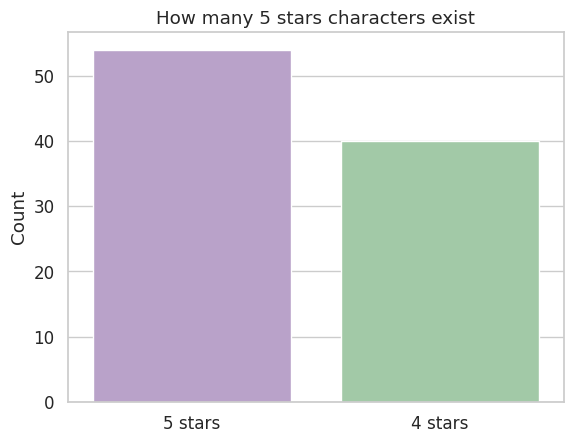

In [ ]:
palette_2=["#ba9bd0","#9bd0a2"]#pastel purple and green
#turn into a string so the axis looks cleaner
df['star_rarity_str'] = df['star_rarity'].map({5:'5 stars', 4:'4 stars'})

#we use x and hue as the same variable
sns.countplot(x='star_rarity_str', hue='star_rarity_str', data=df, palette=palette_2)
plt.title('How many 5 stars characters exist')
plt.xlabel('')
plt.ylabel('Count')
plt.legend([],[], frameon=False)
plt.show()

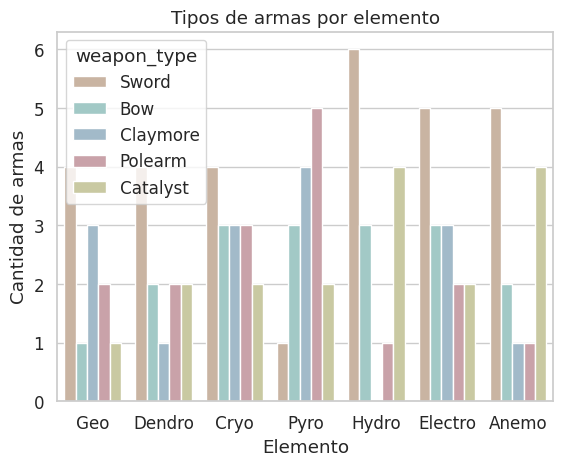

In [ ]:
#creating another grouped bar chart to count the amount of weapon types per element
palette_3= ["#d0b39b", "#9bd0cb", "#9bbbd0", "#d09ba5", "#d0cf9b", "b39ffc", "e88999"]
sns.countplot(x='vision', hue='weapon_type', data=df, palette=palette_3)
plt.title("Tipos de armas por elemento")
plt.xlabel("Elemento")
plt.ylabel("Cantidad de armas")
plt.show()

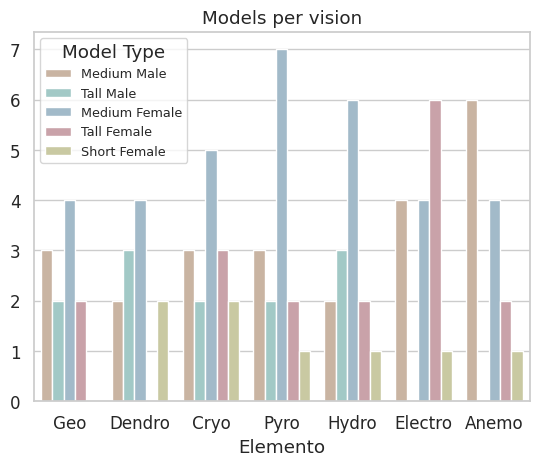

In [ ]:
sns.countplot(x='vision', hue='model', data=df, palette=palette_3)
plt.title("Models per vision")
plt.xlabel('Elemento')
plt.ylabel('')
plt.legend(fontsize='x-small', title='Model Type') # Make legend font size smaller and add title
plt.show()

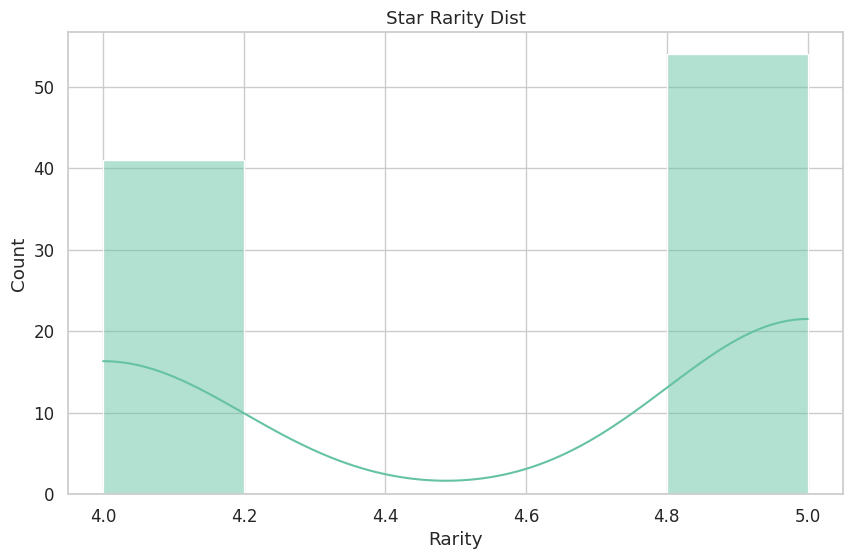

In [ ]:
plt.figure(figsize=(10, 6)) #change the chart's size so it can fit
sns.histplot(df['star_rarity'], bins=5, kde=True)
plt.title('Star Rarity Dist')
plt.xlabel('Rarity')
plt.show()